# Multi-Task Deep Learning for Chess Puzzle Difficulty & Tactical Pattern Prediction

**Course:** 204466 Deep Learning  
**Dataset:** [Lichess Puzzle Database](https://database.lichess.org/#puzzles)

## Pipeline
1. Install dependencies & clone repo
2. Download Lichess puzzle CSV
3. Train all models (SingleTaskCNN, MultiTaskCNN)
4. Ablation study: 2 themes vs 4 themes
5. Evaluate & visualise results

In [2]:
# Install dependencies
!pip install chess scikit-learn seaborn matplotlib pandas torch torchvision -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 77.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
!pip install chess scikit-learn seaborn datasets tqdm -q

In [4]:
# Reload custom modules to pick up changes after file modification
import importlib
import train
import models
import dataset
import evaluate
import experiment
import ablation
import run_experiment

importlib.reload(train)
importlib.reload(models)
importlib.reload(dataset)
importlib.reload(evaluate)
importlib.reload(experiment)
importlib.reload(ablation)
importlib.reload(run_experiment)

print('Reloaded custom modules.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/279M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/279M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/279M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5829565 [00:00<?, ? examples/s]

Reloaded custom modules.


In [6]:
# Install HuggingFace datasets
!pip install datasets -q

from datasets import load_dataset

print("Downloading Lichess puzzle dataset from HuggingFace...")
hf_data = load_dataset("Lichess/chess-puzzles", split="train")
print(f"Loaded {len(hf_data):,} puzzles")
print("Columns:", hf_data.column_names)

Loaded 5,829,565 puzzles
Columns: ['PuzzleId', 'GameId', 'FEN', 'Moves', 'Rating', 'RatingDeviation', 'Popularity', 'NbPlays', 'Themes', 'OpeningTags']


In [7]:
# Quick data inspection
import pandas as pd

df = hf_data.to_pandas().head(5)
print('Columns:', df.columns.tolist())
df.head()

Columns: ['PuzzleId', 'GameId', 'FEN', 'Moves', 'Rating', 'RatingDeviation', 'Popularity', 'NbPlays', 'Themes', 'OpeningTags']


,PuzzleId,GameId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,OpeningTags
0,00008,787zsVup/black#48,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,2107,78,95,9243,"[crushing, hangingPiece, long, middlegame]",None
1,0000D,F8M8OS71#53,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1535,73,95,35791,"[advantage, endgame, short]",None
2,0008Q,MQSyb3KW#127,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1385,80,92,762,"[advantage, endgame, rookEndgame, short]",None
3,0009B,4MWQCxQ6/black#32,r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...,b6c5 e2g4 h3g4 d1g4,1084,74,88,605,"[advantage, middlegame, short]","[Kings_Pawn_Game, Kings_Pawn_Game_Leonardis_Va..."
4,000Pw,au2lCK5o#73,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1542,75,92,622,"[crushing, endgame, fork, short]",None


In [8]:
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [9]:
# Import project modules
from dataset  import build_dataloaders, SUBSET_2, SUBSET_4
from models import build_model
import train as train_module
from train import train as train_fn
from evaluate import evaluate as evaluate_fn, plot_training_history, plot_confusion_matrix, plot_rating_scatter

In [12]:
train_loader, val_loader, test_loader, le, num_themes = build_dataloaders(
    hf_data,
    themes=SUBSET_4,
    batch_size=256
)
LABEL_NAMES = list(le.classes_)
print('Label names:', LABEL_NAMES)

[dataset] Total puzzles loaded : 5,829,565
[dataset] After rating filter  : 4,332,037
[dataset] After plays filter   : 3,760,751
[dataset] After theme filter   : 1,592,732
[dataset] After sampling       : 50,000
primary_theme
pin       12500
fork      12500
skewer    12500
mate      12500
Label names: [np.str_('fork'), np.str_('mate'), np.str_('pin'), np.str_('skewer')]


In [13]:
# Fix train.py: Remove 'verbose=True' from ReduceLROnPlateau
!sed -i 's/, verbose=True//g' /content/train.py
print('Removed verbose=True from ReduceLROnPlateau in train.py')

Removed verbose=True from ReduceLROnPlateau in train.py


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


[train] Using device: cuda


train:   0%|          | 0/137 [00:00<?, ?it/s]

val:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 001/30 | Train Loss 0.0650 MAE 314.5 | Val Loss 0.0594 MAE 297.8 | 13.9s
  ✓ Saved best model (val MAE=297.79)


train:   0%|          | 0/137 [00:00<?, ?it/s]

...

val:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 020/30 | Train Loss 0.0376 MAE 233.7 | Val Loss 0.0511 MAE 273.6 | 10.6s


train:   0%|          | 0/137 [00:00<?, ?it/s]

val:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 021/30 | Train Loss 0.0371 MAE 232.3 | Val Loss 0.0504 MAE 271.7 | 11.6s
[train] Early stopping at epoch 21 (patience=6)
[train] Training complete. Best val MAE: 263.33


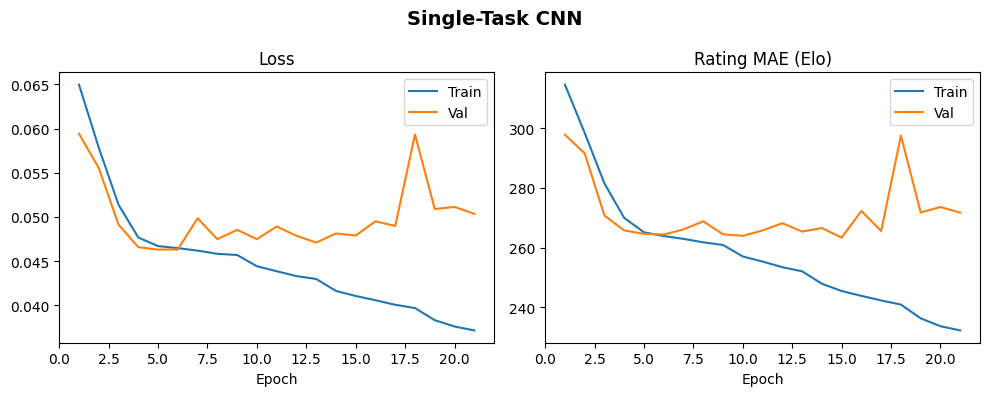

In [15]:
# Train Baseline 2: Single-Task CNN
single_model = models.build_model('single', num_themes=num_themes)

single_history = train_fn(
    single_model, train_loader, val_loader,
    model_type='single', epochs=30, lr=1e-3,
    patience=6, save_path='/content/drive/MyDrive/chess_puzzle_dl/best_single.pt', device=DEVICE
)

plot_training_history(single_history, title='Single-Task CNN')


  Rating MAE  : 263.60 Elo
  Rating RMSE : 331.74 Elo



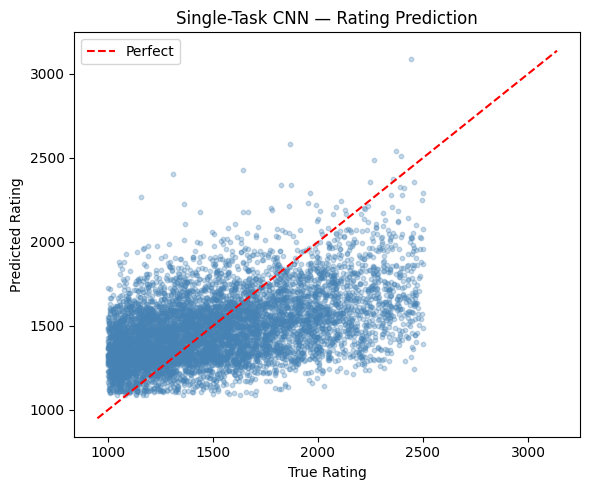

In [16]:
# Evaluate Single-Task CNN
single_results = evaluate.evaluate(
    single_model, test_loader,
    model_type='single', device=DEVICE
)
plot_rating_scatter(single_results, title='Single-Task CNN — Rating Prediction')

[train] Using device: cuda


train:   0%|          | 0/137 [00:00<?, ?it/s]

val:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 001/30 | Train Loss 0.2007 MAE 316.3 | Val Loss 0.1887 MAE 311.5 | 11.6s | ThemeAcc 0.368 F1 0.282
  ✓ Saved best model (val MAE=311.49)


train:   0%|          | 0/137 [00:00<?, ?it/s]

...

val:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 017/30 | Train Loss 0.1288 MAE 244.8 | Val Loss 0.1601 MAE 262.2 | 11.6s | ThemeAcc 0.522 F1 0.523


train:   0%|          | 0/137 [00:00<?, ?it/s]

val:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 018/30 | Train Loss 0.1263 MAE 243.1 | Val Loss 0.1658 MAE 259.7 | 11.6s | ThemeAcc 0.511 F1 0.492
[train] Early stopping at epoch 18 (patience=6)
[train] Training complete. Best val MAE: 258.87


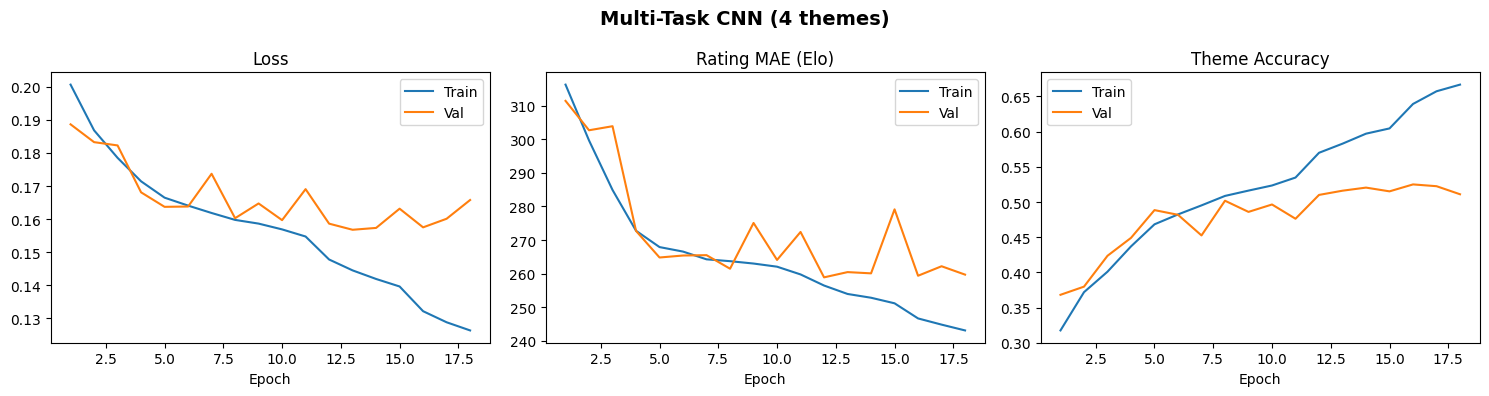

In [17]:
# Train Main Model: Multi-Task CNN (4 themes)
multi_model = models.build_model('multi', num_themes=num_themes)

multi_history = train_fn(
    multi_model, train_loader, val_loader,
    model_type='multi', epochs=30, lr=1e-3,
    patience=6, save_path='/content/drive/MyDrive/chess_puzzle_dl/best_multi.pt', device=DEVICE
)

plot_training_history(multi_history, title='Multi-Task CNN (4 themes)')

Modified evaluate.py to handle multi-task loader unpacking and model input.
Reloaded evaluate module.
              precision    recall  f1-score   support

        fork       0.43      0.55      0.49      1875
        mate       0.57      0.43      0.49      1875
         pin       0.44      0.49      0.47      1875
      skewer       0.68      0.58      0.62      1875

    accuracy                           0.51      7500
   macro avg       0.53      0.51      0.52      7500
weighted avg       0.53      0.51      0.52      7500


  Rating MAE  : 261.09 Elo
  Rating RMSE : 324.85 Elo
  Theme Acc   : 0.5148
  Theme F1 macro    : 0.5177
  Theme F1 weighted : 0.5177



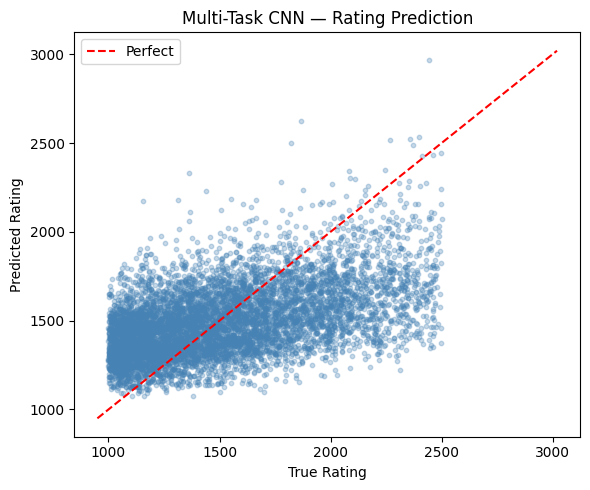

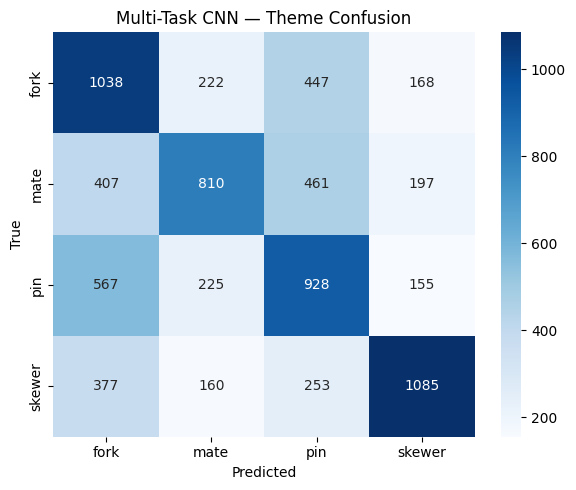

In [18]:
# Evaluate Multi-Task CNN
import importlib
import evaluate
importlib.reload(evaluate)

print('Reloaded evaluate module.')

multi_results = evaluate.evaluate(
    multi_model, test_loader,
    model_type='multi', device=DEVICE, label_names=LABEL_NAMES
)
plot_rating_scatter(multi_results, title='Multi-Task CNN — Rating Prediction')
plot_confusion_matrix(multi_results, LABEL_NAMES, title='Multi-Task CNN — Theme Confusion')

In [19]:
# Model Comparison Summary
import pandas as pd

comparison = pd.DataFrame([
    {'Model': 'SingleTaskCNN',
     'MAE (Elo)' : single_results['mae'],
     'RMSE (Elo)': single_results['rmse'],
     'Theme Acc' : '—',
     'Theme F1 macro'  : '—'},
    {'Model': 'MultiTaskCNN (4 themes)',
     'MAE (Elo)' : multi_results['mae'],
     'RMSE (Elo)': multi_results['rmse'],
     'Theme Acc' : round(multi_results.get('theme_acc', 0), 4),
     'Theme F1 macro'  : round(multi_results.get('theme_f1',  0), 4)},
])
print(comparison.to_string(index=False))

                  Model  MAE (Elo)  RMSE (Elo) Theme Acc Theme F1 macro
          SingleTaskCNN 263.595825  331.738892         —              —
MultiTaskCNN (4 themes) 261.086273  324.853394    0.5148         0.5177


In [22]:
# ABLATION STUDY: 2 themes vs 4 themes
ablation_rows = []

for themes, tag in [(SUBSET_2, '2themes'), (SUBSET_4, '4themes')]:
    print(f'\n--- Ablation: {tag} ---')
    tr, va, te, le_abl, nt = build_dataloaders(hf_data, themes=themes, batch_size=256)
    m = build_model('multi', num_themes=nt)
    h = train_fn(m, tr, va, model_type='multi', epochs=30, lr=1e-3,
              patience=6, save_path=f'/content/drive/MyDrive/chess_puzzle_dl/best_abl_{tag}.pt',
    device=DEVICE)
    r = evaluate.evaluate(m, te, model_type='multi', device=DEVICE, label_names=list(le_abl.classes_))
    ablation_rows.append({
        'Experiment': tag,
        'Themes'    : ', '.join(themes),
        'MAE (Elo)' : r['mae'],
        'RMSE (Elo)': r['rmse'],
        'Theme F1 macro'  : round(r.get('theme_f1', 0), 4),
    })

abl_df = pd.DataFrame(ablation_rows)
print('\nABLATION STUDY RESULTS:')
print(abl_df.to_string(index=False))


--- Ablation: 2themes ---
[dataset] Total puzzles loaded : 5,829,565
[dataset] After rating filter  : 4,332,037
[dataset] After plays filter   : 3,760,751
[dataset] After theme filter   : 1,296,271
[dataset] After sampling       : 50,000
primary_theme
mate    25000
fork    25000
[train] Using device: cuda


train:   0%|          | 0/137 [00:00<?, ?it/s]

val:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 001/30 | Train Loss 0.1245 MAE 288.4 | Val Loss 0.1212 MAE 276.5 | 11.7s | ThemeAcc 0.563 F1 0.547
  ✓ Saved best model (val MAE=276.53)


train:   0%|          | 0/137 [00:00<?, ?it/s]

...

val:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 018/30 | Train Loss 0.1251 MAE 243.4 | Val Loss 0.1620 MAE 262.4 | 12.1s | ThemeAcc 0.526 F1 0.523


train:   0%|          | 0/137 [00:00<?, ?it/s]

val:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 019/30 | Train Loss 0.1223 MAE 242.0 | Val Loss 0.1658 MAE 271.4 | 11.6s | ThemeAcc 0.521 F1 0.514
[train] Early stopping at epoch 19 (patience=6)
[train] Training complete. Best val MAE: 258.14
              precision    recall  f1-score   support

        fork       0.48      0.46      0.47      1875
        mate       0.53      0.54      0.54      1875
         pin       0.45      0.50      0.48      1875
      skewer       0.65      0.60      0.62      1875

    accuracy                           0.53      7500
   macro avg       0.53      0.53      0.53      7500
weighted avg       0.53      0.53      0.53      7500


  Rating MAE  : 259.52 Elo
  Rating RMSE : 323.74 Elo
  Theme Acc   : 0.5253
  Theme F1 macro    : 0.5267
  Theme F1 weighted : 0.5267


ABLATION STUDY RESULTS:
Experiment                  Themes  MAE (Elo)  RMSE (Elo)  Theme F1 macro
   2themes              fork, mate 240.930222  304.405212          0.7549
   4themes fork, pin, skewer, mate 259.519745  323.743

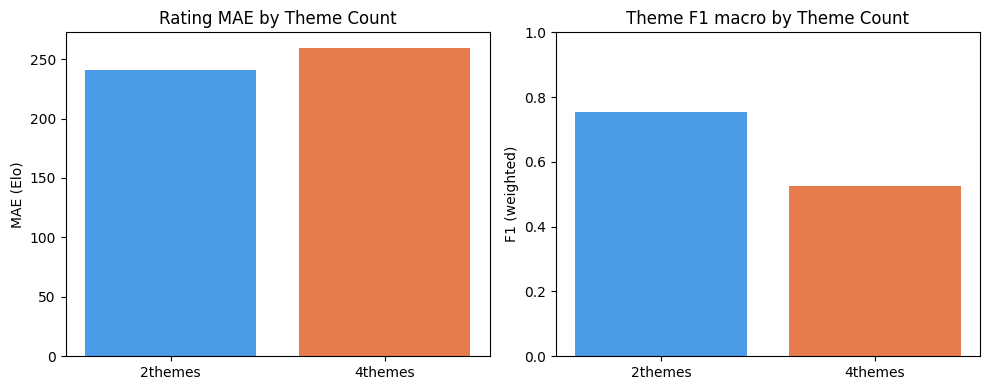

In [23]:
# Ablation bar chart
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(abl_df['Experiment'], abl_df['MAE (Elo)'], color=['#4C9BE8','#E87B4C'])
axes[0].set_title('Rating MAE by Theme Count'); axes[0].set_ylabel('MAE (Elo)')

axes[1].bar(abl_df['Experiment'], abl_df['Theme F1 macro'], color=['#4C9BE8','#E87B4C'])
axes[1].set_title('Theme F1 macro by Theme Count'); axes[1].set_ylabel('F1 (weighted)')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('ablation_comparison.png', dpi=150)
plt.show()

In [24]:
# Save all results
comparison.to_csv('model_comparison.csv', index=False)
abl_df.to_csv('ablation_results.csv',     index=False)
print('Saved model_comparison.csv and ablation_results.csv')

Saved model_comparison.csv and ablation_results.csv
